# Celda 1: Instalación e Importación de Dependencias

Si no tienes instaladas las librerías necesarias en tu entorno de Conda, descomenta la siguiente línea y ejecútala:
```bash
!pip install segmentation-models-pytorch albumentations opencv-python matplotlib
```


In [1]:
import os
# Evitar crash de OpenMP duplicado (error libiomp5md.dll en Windows/Conda)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# Validar soporte GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=== CONFIGURACIÓN DEL ENTORNO ===")
print("PyTorch versión:", torch.__version__)
print("CUDA (GPU) disponible:", torch.cuda.is_available())
print("Dispositivo seleccionado para entrenamiento:", device)


=== CONFIGURACIÓN DEL ENTORNO ===
PyTorch versión: 2.5.1+cu121
CUDA (GPU) disponible: True
Dispositivo seleccionado para entrenamiento: cuda


# Celda 2: Dataset y Dataloaders con Albumentations

Definimos la clase `SkinDataset` para leer imágenes (RGB) y máscaras indexadas (un canal con IDs 0, 1, 2, 3).
Configuramos la aumentación de datos para el entrenamiento para evitar el sobreajuste.


In [2]:
class SkinDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        """
        Args:
            images_dir (str): Directorio con las imágenes de entrada.
            masks_dir (str): Directorio con las máscaras objetivo (.png).
            transform (albumentations.Compose): Transformaciones a aplicar.
        """
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        
        # Indexar imágenes válidas
        self.image_names = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
        
    def __len__(self):
        return len(self.image_names)
        
    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.images_dir, img_name)
        
        # Encontrar la máscara correspondiente (siempre en formato PNG)
        base_name, _ = os.path.splitext(img_name)
        msk_name = f"{base_name}.png"
        msk_path = os.path.join(self.masks_dir, msk_name)
        
        # 1. Cargar imagen en BGR y convertir a RGB
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"No se pudo cargar la imagen: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # 2. Cargar máscara en escala de grises
        mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            # Si falta la máscara (caso atípico), inicializamos con ceros (fondo)
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
            
        # 3. Aplicar transformaciones conjuntas (Imagen y Máscara)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        # Retornar la máscara de píxeles como LongTensor para CrossEntropyLoss
        return image, mask.long()


# Transformaciones de Albumentations para Entrenamiento
# Nota: Ajustamos las aumentaciones para que sean sutiles en la piel
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.Affine(
        translate_percent=(-0.05, 0.05),
        scale=(0.95, 1.05),
        rotate=(-15, 15),
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        p=0.5
    ),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Transformaciones de Validación (Solo normalización estándar de ImageNet)
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Definición de rutas del dataset consolidado
dataset_root = "./dataset_unet_final"
train_images_dir = os.path.join(dataset_root, "images", "train")
train_masks_dir = os.path.join(dataset_root, "masks", "train")
val_images_dir = os.path.join(dataset_root, "images", "val")
val_masks_dir = os.path.join(dataset_root, "masks", "val")

# Instanciación de datasets
train_dataset = SkinDataset(train_images_dir, train_masks_dir, transform=train_transform)
val_dataset = SkinDataset(val_images_dir, val_masks_dir, transform=val_transform)

# Configuración de DataLoaders
# num_workers=0 se selecciona para evitar errores de hilos en Windows (spawn multiprocessing)
BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"[+] Dataset de Entrenamiento: {len(train_dataset)} muestras.")
print(f"[+] Dataset de Validación: {len(val_dataset)} muestras.")


[+] Dataset de Entrenamiento: 1785 muestras.
[+] Dataset de Validación: 316 muestras.


# Celda 3: Definición del Modelo U-Net con Segmentation Models PyTorch

Instanciamos una arquitectura U-Net con encoder `resnet34` cargado con pesos preentrenados de ImageNet.


In [3]:
# Configuración del modelo U-Net
# - encoder_name: resnet34 (buen balance velocidad/exactitud)
# - encoder_weights: imagenet (pesos preentrenados)
# - in_channels: 3 (Imágenes RGB de 3 canales)
# - classes: 4 (Nuestras clases: Fondo, Acné, Manchas, Arrugas)
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4
)

# Enviar modelo al hardware seleccionado
model.to(device)
print(f"[+] Modelo U-Net (ResNet34) inicializado con éxito en: {device}")


[+] Modelo U-Net (ResNet34) inicializado con éxito en: cuda


# Celda 4: Función de Pérdida Combinada y Métricas

Usamos una pérdida combinada de Dice Loss (optimiza regiones de anomalías) y Cross Entropy (optimiza píxeles).
Definimos el cálculo del Jaccard Index (IoU) global por clase.


In [4]:
class CombinedLoss(nn.Module):
    def __init__(self):
        super(CombinedLoss, self).__init__()
        # DiceLoss configurado para multiclase, asumiendo logits directos como entrada
        self.dice_loss = smp.losses.DiceLoss(mode="multiclass", from_logits=True)
        self.ce_loss = nn.CrossEntropyLoss()
        
    def forward(self, y_pred, y_true):
        # y_pred: Tensor [Batch, 4, H, W] (logits)
        # y_true: Tensor [Batch, H, W] (class indices)
        dice = self.dice_loss(y_pred, y_true)
        ce = self.ce_loss(y_pred, y_true)
        return dice + ce

criterion = CombinedLoss()

def calculate_mean_iou(preds, targets, num_classes=4):
    """
    Calcula el Mean IoU (Intersection over Union) de un batch.
    """
    iou_list = []
    eps = 1e-6
    
    for class_id in range(num_classes):
        pred_class = (preds == class_id)
        target_class = (targets == class_id)
        
        intersection = (pred_class & target_class).sum().item()
        union = (pred_class | target_class).sum().item()
        
        if union == 0:
            # Si no hay píxeles de esta clase predichos ni anotados en el batch
            iou_list.append(1.0)
        else:
            iou_list.append(intersection / (union + eps))
            
    return np.mean(iou_list)

print("[+] Pérdidas y métrica de IoU listas.")


[+] Pérdidas y métrica de IoU listas.


# Celda 5: Bucle de Entrenamiento y Validación

Configuramos el optimizador Adam y el bucle principal de entrenamiento. Guardaremos el mejor checkpoint.


In [12]:
# 1. Instanciar Optimizador y Scheduler (Tasa de aprendizaje adaptativa)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Reducirá el LR a la mitad (factor=0.5) si el Val Loss no mejora en 3 épocas
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=3
)

# 2. Función para entrenar una sola Época
def train_one_epoch(model, loader, criterion, optimizer, device, epoch, num_epochs):
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    running_acc = 0.0
    total_batches = len(loader)
    
    # Barra de progreso tqdm para el lote de entrenamiento actual
    pbar = tqdm(enumerate(loader), total=total_batches, desc=f"Época [{epoch+1:02d}/{num_epochs:02d}] Train", leave=False)
    
    for step, (images, masks) in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)  # Inferencia
        
        loss = criterion(outputs, masks)  # Calcular costo
        loss.backward()  # Calcular gradientes
        optimizer.step()  # Ajustar pesos matemáticos
        
        loss_val = loss.item()
        running_loss += loss_val
        
        # Calcular predicciones discretas e IoU por lote
        preds = torch.argmax(outputs, dim=1)
        iou_val = calculate_mean_iou(preds, masks)
        running_iou += iou_val
        
        # Calcular Pixel Accuracy (Exactitud de píxeles)
        acc_val = (preds == masks).float().mean().item()
        running_acc += acc_val
        
        # Actualizar información dinámica en la barra de progreso de Jupyter
        pbar.set_postfix({
            "Batch": f"{step+1}/{total_batches}",
            "Loss": f"{loss_val:.4f}",
            "mIoU": f"{iou_val:.4f}",
            "Acc": f"{acc_val:.4f}"
        })
        
    return running_loss / total_batches, running_iou / total_batches, running_acc / total_batches


# 3. Función para validar una sola Época
def validate_one_epoch(model, loader, criterion, device, epoch, num_epochs):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_acc = 0.0
    total_batches = len(loader)
    
    # Barra de progreso tqdm para validación
    pbar = tqdm(enumerate(loader), total=total_batches, desc=f"Época [{epoch+1:02d}/{num_epochs:02d}] Val", leave=False)
    
    with torch.no_grad():
        for step, (images, masks) in pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            loss_val = loss.item()
            running_loss += loss_val
            
            preds = torch.argmax(outputs, dim=1)
            iou_val = calculate_mean_iou(preds, masks)
            running_iou += iou_val
            
            acc_val = (preds == masks).float().mean().item()
            running_acc += acc_val
            
            pbar.set_postfix({
                "Batch": f"{step+1}/{total_batches}",
                "Loss": f"{loss_val:.4f}",
                "mIoU": f"{iou_val:.4f}",
                "Acc": f"{acc_val:.4f}"
            })
            
    return running_loss / total_batches, running_iou / total_batches, running_acc / total_batches


# 4. Configuración del bucle global de entrenamiento
EPOCHS = 50  # Sube el valor a 30, 40 o 50 para el entrenamiento de alta precisión de tu MVP
best_val_loss = float('inf')
best_model_path = "best_model.pth"

print(f"[+] Iniciando ciclo de entrenamiento por {EPOCHS} épocas en {device}...")

for epoch in range(EPOCHS):
    # Ejecutar pasos de entrenamiento y validación por época
    train_loss, train_iou, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch, EPOCHS)
    val_loss, val_iou, val_acc = validate_one_epoch(model, val_loader, criterion, device, epoch, EPOCHS)
    
    # 5. Actualizar planificador (Scheduler) basándonos en la pérdida de validación
    scheduler.step(val_loss)
    
    # Obtener el Learning Rate actual de la época para monitoreo
    current_lr = optimizer.param_groups[0]['lr']
    
    # Imprimir métricas consolidadas en consola
    print(f"Época [{epoch+1:02d}/{EPOCHS:02d}] | "
          f"Train Loss: {train_loss:.4f} - Train mIoU: {train_iou:.4f} - Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} - Val mIoU: {val_iou:.4f} - Val Acc: {val_acc:.4f} | "
          f"LR: {current_lr:.2e}")
          
    # 6. Guardar el mejor modelo en disco si reduce el Val Loss previo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"  [+] ¡Nuevo récord! Se guardó un mejor modelo con Val Loss: {val_loss:.4f} en '{best_model_path}'")

print(f"\n[+] Entrenamiento finalizado exitosamente. El mejor modelo guardado tiene un Val Loss de: {best_val_loss:.4f}")

[+] Iniciando ciclo de entrenamiento por 50 épocas en cuda...


Época [01/50] Train:   0%|          | 0/224 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Celda 6: Visualización de Resultados de Inferencia

Cargamos los pesos guardados en `best_model.pth` y visualizamos predicciones del set de validación.


[+] Pesos cargados exitosamente de 'best_model.pth'


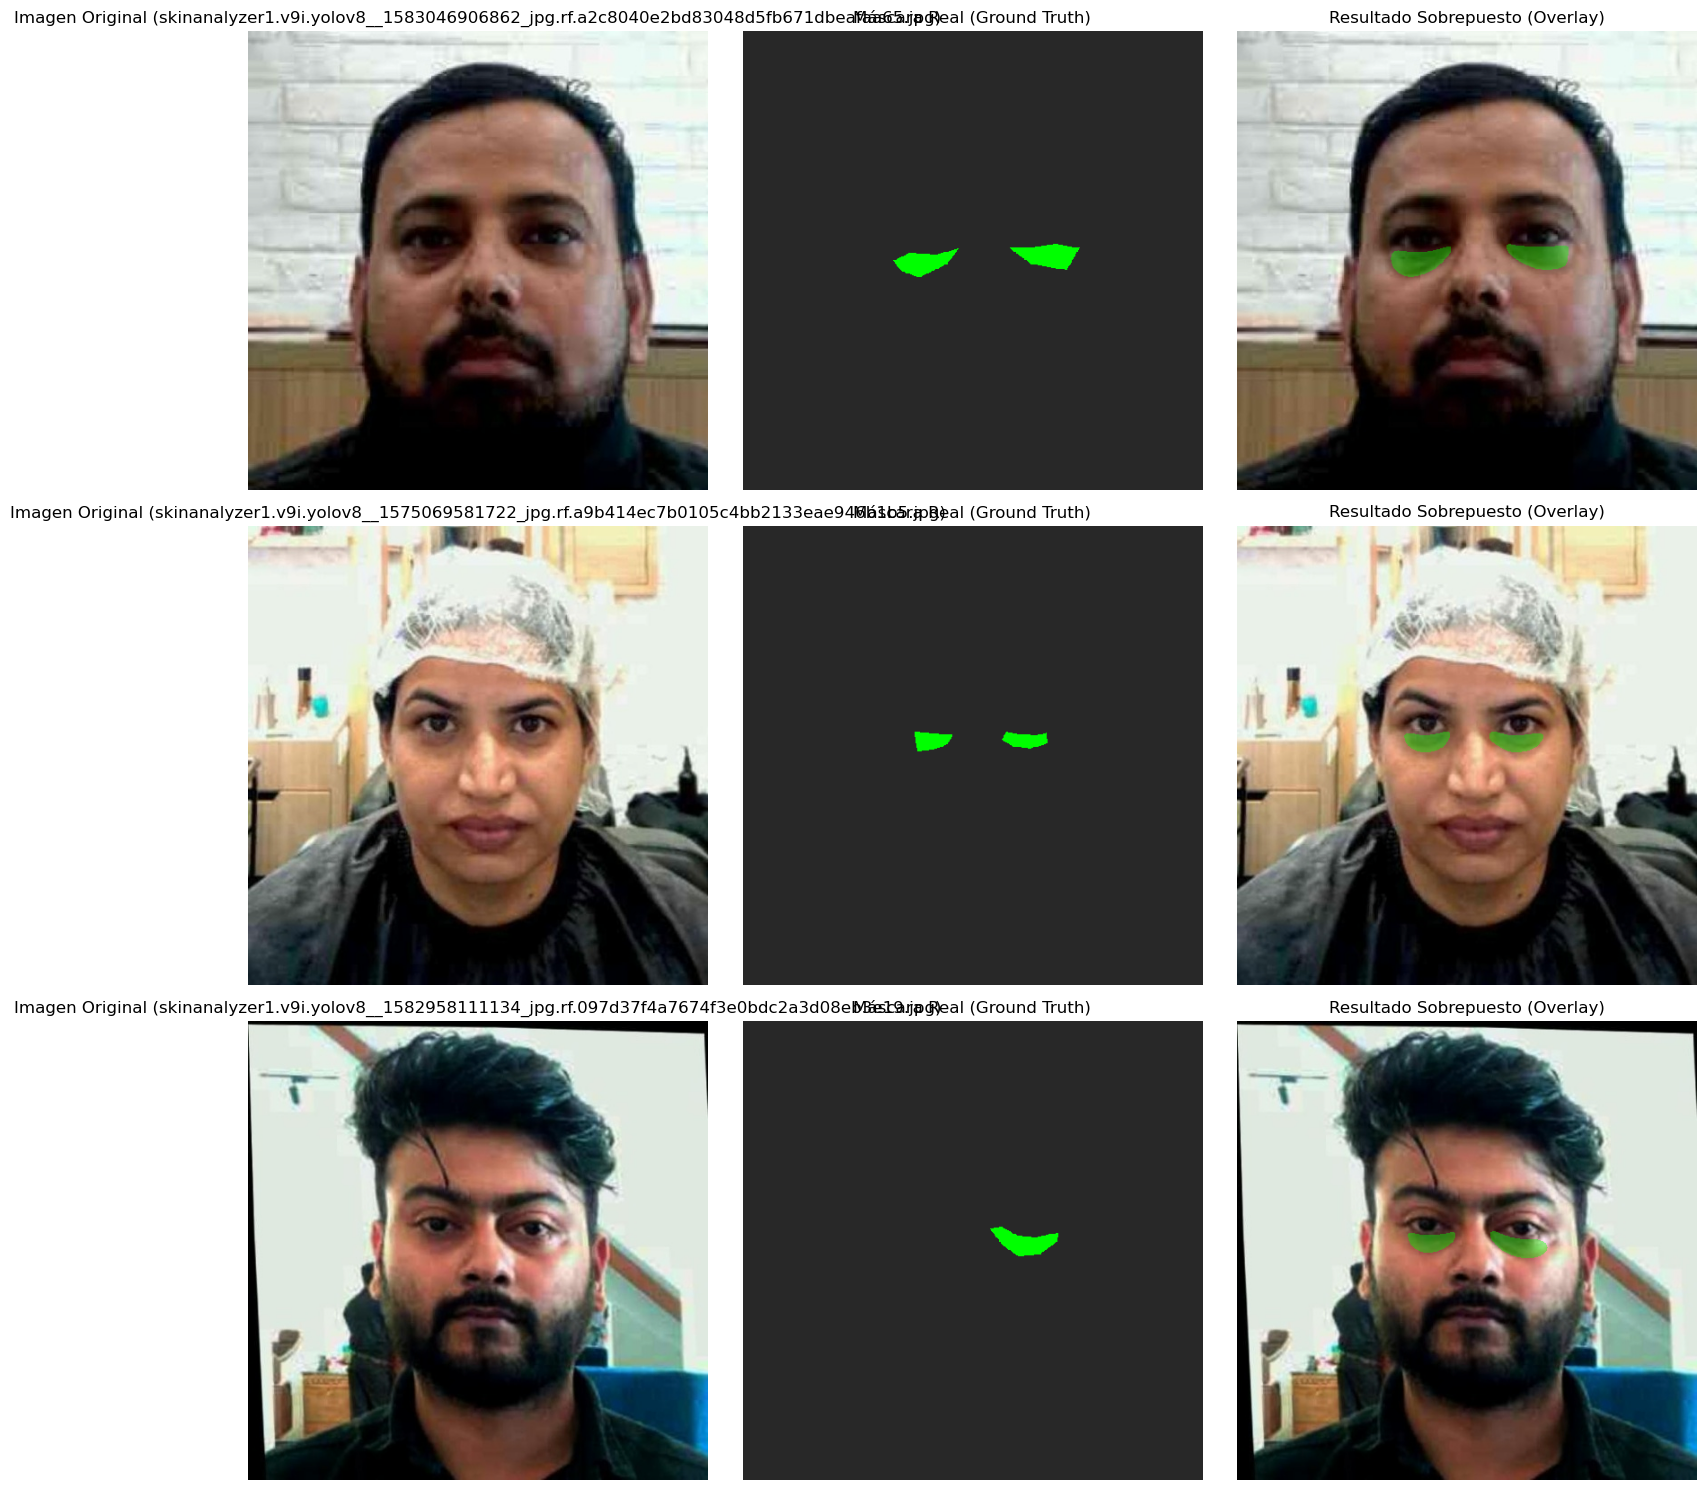

In [6]:
# =====================================================================
# CELDA 6: Visualización de Resultados (Imagen, Máscara y Máscara Sobrepuesta)
# =====================================================================

# 1. Cargar mejores pesos corregido para evitar warnings
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True)) #
    print(f"[+] Pesos cargados exitosamente de '{best_model_path}'") #
else:
    print("[!] Checkpoint no encontrado. Utilizando pesos actuales de memoria.") #

model.eval() #[cite: 3]

# Paleta de Colores en RGB para las máscaras
# 0: Fondo (No se usará en el overlay transparente)
# 1: Acné -> Rojo [255, 0, 0]
# 2: Manchas -> Verde [0, 255, 0]
# 3: Arrugas -> Azul [0, 0, 255]
color_palette = np.array([
    [0, 0, 0],         # Fondo (Clase 0)[cite: 3]
    [255, 0, 0],       # Acné (Clase 1)[cite: 3]
    [0, 255, 0],       # Manchas (Clase 2)[cite: 3]
    [0, 0, 255]        # Arrugas (Clase 3)[cite: 3]
], dtype=np.uint8)

# Parámetros de denormalización de ImageNet
mean = np.array([0.485, 0.456, 0.406]) #[cite: 3]
std = np.array([0.229, 0.224, 0.225]) #[cite: 3]

# Tomar 3 imágenes aleatorias de validación
samples_to_show = 3 #[cite: 3]
indices = random.sample(range(len(val_dataset)), samples_to_show) #[cite: 3]

# Configuramos la visualización en 3 columnas: [Original] | [Máscara de tu U-Net] | [Máscara Sobrepuesta]
fig, axes = plt.subplots(samples_to_show, 3, figsize=(15, 5 * samples_to_show)) #[cite: 3]

for idx, val_idx in enumerate(indices): #[cite: 3]
    image_tensor, mask_tensor = val_dataset[val_idx] #[cite: 3]
    
    # Preparar el tensor para el modelo: [1, 3, H, W]
    input_tensor = image_tensor.unsqueeze(0).to(device) #[cite: 3]
    
    with torch.no_grad(): #[cite: 3]
        output = model(input_tensor) #[cite: 3]
        prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy() #[cite: 3]
        
    # Denormalizar imagen para visualización RGB
    img_np = image_tensor.permute(1, 2, 0).numpy() #[cite: 3]
    img_np = (img_np * std + mean) * 255 #[cite: 3]
    img_np = np.clip(img_np, 0, 255).astype(np.uint8) #[cite: 3]
    
    # Convertir máscara real de validación para comparar visualmente (fondo en gris oscuro)
    mask_np = mask_tensor.numpy() #[cite: 3]
    visual_palette = color_palette.copy()
    visual_palette[0] = [40, 40, 40]  # Pinta el fondo gris oscuro para ver la máscara pura[cite: 3]
    gt_color = visual_palette[mask_np] #[cite: 3]
    
    # --- PROCESO DE MÁSCARA SOBREPUESTA (OVERLAY) ---
    # 1. Crear una copia de la imagen original
    overlay_img = img_np.copy()
    
    # 2. Mapear las clases predichas a sus colores correspondientes
    pred_color_rgb = color_palette[prediction]
    
    # 3. Crear una máscara binaria de las detecciones (píxeles donde clase > 0)
    detection_mask = (prediction > 0).astype(np.uint8)
    
    # 4. En los píxeles donde se detectó anomalía, mezclamos la imagen con el color
    # Alpha controla la opacidad (0.4 = 40% color de la máscara, 60% la piel del usuario)
    alpha = 0.4
    for c in range(3):  # Iterar sobre los canales R, G, B
        overlay_img[:, :, c] = np.where(
            detection_mask == 1,
            (alpha * pred_color_rgb[:, :, c] + (1 - alpha) * img_np[:, :, c]).astype(np.uint8),
            img_np[:, :, c]
        )
    # ------------------------------------------------
    
    # Manejar subplots de 1 fila vs múltiples
    ax_orig = axes[idx, 0] if samples_to_show > 1 else axes[0] #[cite: 3]
    ax_gt = axes[idx, 1] if samples_to_show > 1 else axes[1] #[cite: 3]
    ax_pred = axes[idx, 2] if samples_to_show > 1 else axes[2] #[cite: 3]
    
    # 1. Imagen original
    ax_orig.imshow(img_np) #[cite: 3]
    ax_orig.set_title(f"Imagen Original ({val_dataset.image_names[val_idx]})") #[cite: 3]
    ax_orig.axis("off") #[cite: 3]
    
    # 2. Máscara de tu U-Net (Ground Truth de validación)
    ax_gt.imshow(gt_color) #[cite: 3]
    ax_gt.set_title("Máscara Real (Ground Truth)") #[cite: 3]
    ax_gt.axis("off") #[cite: 3]
    
    # 3. Máscara sobrepuesta a la imagen original (Inferencia final del Producto)
    ax_pred.imshow(overlay_img)
    ax_pred.set_title("Resultado Sobrepuesto (Overlay)")
    ax_pred.axis("off") #[cite: 3]

plt.tight_layout() #[cite: 3]
plt.show() #[cite: 3]

[+] Procesando archivo: C:/Users/AndresV/Downloads/images (2).jpg


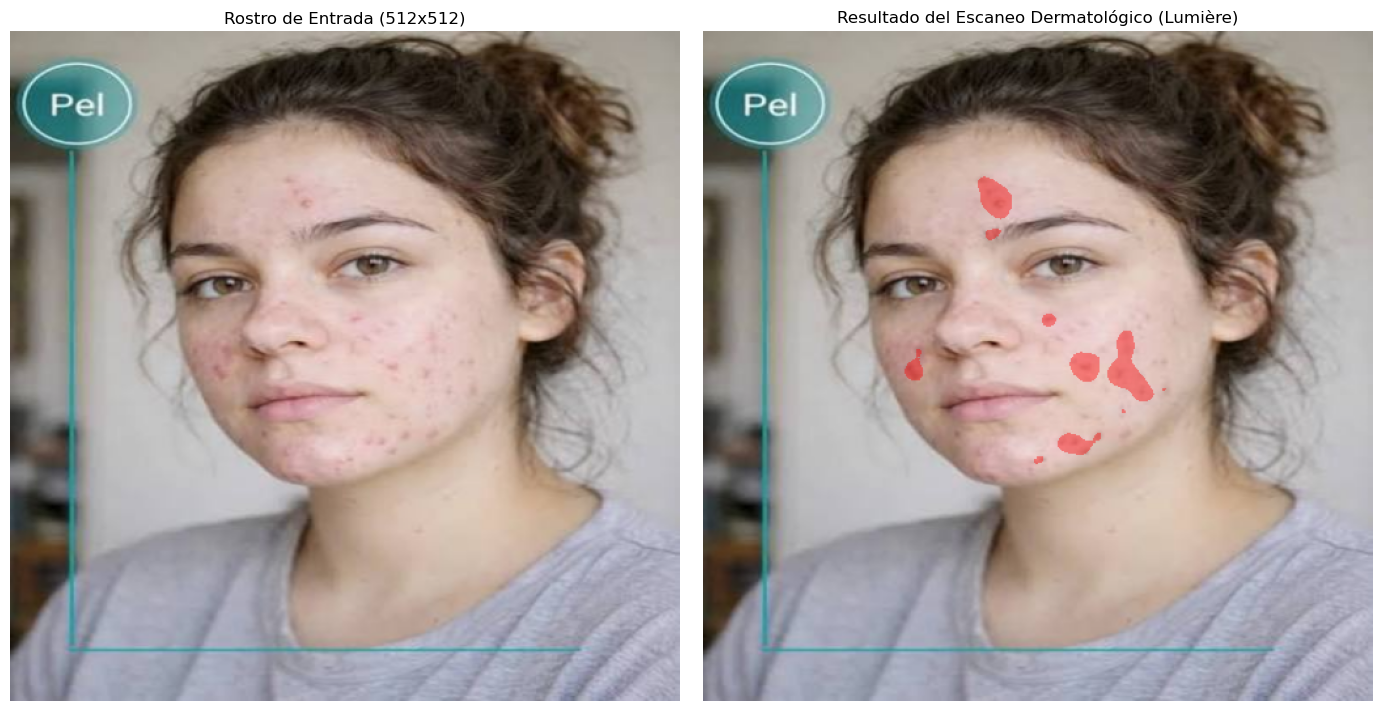


=== REPORTE DE ANÁLISIS DE PIEL ===
Anomalías estructurales localizadas:
 -> [+] Acné (10 focos)


In [13]:
# =====================================================================
# CELDA 7: Inferencia Interactiva con Explorador de Archivos de Windows
# =====================================================================

import tkinter as tk
from tkinter import filedialog
from PIL import Image

def seleccionar_y_predecir():
    # 1. Crear una ventana oculta de Tkinter para abrir el explorador de archivos
    root = tk.Tk()
    root.withdraw()  # Ocultar la ventana principal de Tkinter
    root.attributes('-topmost', True)  # Forzar que la ventana del explorador aparezca al frente
    
    # 2. Abrir el cuadro de diálogo para seleccionar la imagen
    file_path = filedialog.askopenfilename(
        title="Selecciona una foto de rostro para el análisis de Lumière",
        filetypes=[("Imágenes", "*.jpg *.jpeg *.png *.webp")]
    )
    
    # Destruir la instancia de Tkinter para liberar recursos de memoria
    root.destroy()
    
    if not file_path:
        print("[!] No se seleccionó ningún archivo.")
        return
        
    print(f"[+] Procesando archivo: {file_path}")
    
    # 3. Cargar la imagen seleccionada y guardarla en su resolución original para visualización
    orig_img_bgr = cv2.imread(file_path)
    if orig_img_bgr is None:
        print("[!] Error: No se pudo cargar la imagen.")
        return
    orig_img_rgb = cv2.cvtColor(orig_img_bgr, cv2.COLOR_BGR2RGB)
    
    # 4. Preprocesar la imagen con el tamaño exacto que espera la U-Net (512x512)
    resized_img = cv2.resize(orig_img_rgb, (512, 512), interpolation=cv2.INTER_LINEAR)
    
    # Normalización estándar de ImageNet (idéntica a val_transform en la Celda 2)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    normalized_img = (resized_img / 255.0 - mean) / std
    
    # Convertir a Tensor de PyTorch [C, H, W] y agregar dimensión de Batch [1, C, H, W]
    input_tensor = torch.tensor(normalized_img).permute(2, 0, 1).float().unsqueeze(0).to(device)
    
    # 5. Ejecución de la inferencia en la red neuronal[cite: 3]
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        # argmax para obtener los IDs de clases ganadores en cada píxel[cite: 3]
        prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        
    # 6. --- GENERAR MÁSCARA SOBREPUESTA (OVERLAY) ---
    # Paleta de colores para anomalías (Clase 0: transparente, 1: rojo, 2: verde, 3: azul)[cite: 3]
    color_palette = np.array([
        [0, 0, 0],         # Fondo (Clase 0)[cite: 3]
        [255, 0, 0],       # Acné (Clase 1)[cite: 3]
        [0, 255, 0],       # Manchas (Clase 2)[cite: 3]
        [0, 0, 255]        # Arrugas (Clase 3)[cite: 3]
    ], dtype=np.uint8)
    
    overlay_img = resized_img.copy()
    pred_color_rgb = color_palette[prediction]
    detection_mask = (prediction > 0).astype(np.uint8)
    
    alpha = 0.4  # Opacidad de la máscara (40% de color de anomalía, 60% piel original)
    for c in range(3):
        overlay_img[:, :, c] = np.where(
            detection_mask == 1,
            (alpha * pred_color_rgb[:, :, c] + (1 - alpha) * resized_img[:, :, c]).astype(np.uint8),
            resized_img[:, :, c]
        )
        
    # 7. --- CONTEO DE ANOMALÍAS DETECTADAS (Para lógica del LLM/Recomendador) ---
    # Contamos componentes conectados en cada canal de predicción (excepto fondo)
    anomalias_detectadas = []
    nombres_clases = {1: "Acné", 2: "Manchas", 3: "Arrugas"}
    
    for class_id, nombre in nombres_clases.items():
        class_mask = (prediction == class_id).astype(np.uint8)
        # findContours cuenta cuántas islas o anomalías individuales de esa clase existen
        num_labels, _ = cv2.connectedComponents(class_mask)
        # connectedComponents cuenta el fondo como la etiqueta 0, restamos 1
        cantidad = max(0, num_labels - 1)
        if cantidad > 0:
            anomalias_detectadas.append(f"{nombre} ({cantidad} focos)")
            
    # 8. Renderizar Resultados
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    axes[0].imshow(resized_img)
    axes[0].set_title("Rostro de Entrada (512x512)")
    axes[0].axis("off")
    
    axes[1].imshow(overlay_img)
    axes[1].set_title("Resultado del Escaneo Dermatológico (Lumière)")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*50)
    print("=== REPORTE DE ANÁLISIS DE PIEL ===")
    if anomalias_detectadas:
        print("Anomalías estructurales localizadas:")
        for item in anomalias_detectadas:
            print(f" -> [+] {item}")
    else:
        print(" -> [+] ¡Piel completamente sana detectada!")
    print("="*50)

# Ejecutar la función interactiva
seleccionar_y_predecir()